## The Effect of Firm Type and Resolution Methods on Dispute Rates

### 1. Introduction

The U.S. private student loan market is worth over $100 billion, but many borrowers struggle when things go wrong. When payment issues arise, the way companies handle the problem matters a lot. Although many reports show that servicing failures are common, we still do not know if the type of company—specifically, traditional Banks versus Specialist Servicers (X)—affects how often consumers file complaints (Dispute Rates, Y). In this project, I investigate this relationship and look at whether the Resolution Strategy (specifically, offering financial relief) acts as the main mechanism (Z) that satisfies consumers.

Existing research agrees that the market has problems, but there is debate about which firms are better. The Consumer Financial Protection Bureau (2015) found that many firms create barriers to repayment, and Hunt (2016) noted that over one-third of complaints are just about bad communication. However, it is unclear if "Specialists" are worse than Banks. Buchak et al. (2018) argue that non-bank lenders often cut corners to save costs, which might mean worse service. On the other hand, Yannelis (2020) suggests that specialists might actually be more efficient at handling debt.

My project connects these ideas by testing a specific mechanism (Z). Di Maggio et al. (2020) showed that "money speaks louder than words"—meaning tangible relief helps borrowers the most. I try to see if Specialist Servicers use this "Relief" strategy to make up for other service issues. My analysis uses data from the CFPB Consumer Complaint Database (Walczak, 2017) merged with a hand-collected dataset of firm characteristics like asset size and enforcement history.

### 2. Data Loading

#### 2.1 Data Sources and Sample Construction
This analysis utilizes the **CFPB Consumer Complaint Database** (via Kaggle, Walczak 2017) covering March 2012 to April 2016. We restricted the sample to the **top 10 student loan servicers**, which capture **82%** of total complaints (10,672 observations), ensuring statistical robustness while removing noise. To test supply-side hypotheses, we merged this data with hand-collected firm characteristics—specifically **Asset Size** (from 2014 SEC 10-K filings) and **Enforcement History** (from DOJ/CFPB records).

#### 2.2 Variable Definitions & Research Design
To investigate the drivers of consumer dissatisfaction, the outcome variable (Y) is defined as the Dispute Rate, a binary measure indicating whether a consumer rejected the company’s initial resolution. The primary independent variable (X) is Institution Type, distinguishing between traditional banks and specialist servicers. I hypothesize that specialist servicers, lacking the broad reputational incentives of banks and operating on a cost-minimization model, may inherently provide lower quality service. However, this relationship is mediated by the Response Strategy (Z), specifically whether a firm offers tangible "Relief" (monetary or non-monetary) versus a simple "Explanation." I expect that "Relief" is the central mechanism that suppresses disputes; therefore, if specialists utilize relief strategies more aggressively to compensate for service errors, they may neutralize the expected gap in dispute rates. Finally, Enforcement History is included as a key control variable to capture the "disciplining effect" of regulation, testing whether a firm’s compliance record is a stronger predictor of consumer-friendly behavior than its organizational structure.

#### 2.3 Cleaning the Original Data Set

In [70]:
import pandas as pd

# Load the raw dataset
df_raw = pd.read_csv('consumer_complaints.csv', low_memory=False)

# Extract only student loan complaints for analysis
df = df_raw[df_raw['product'] == 'Student loan']

#Filter Data: Remove incomplete or untimely responses
df = df[~df['company_response_to_consumer'].isin(['In progress', 'Untimely response'])].copy()

#Standardize Issues: Merge similar issue categories
issue_mapping = {
    'Repaying your loan': 'Dealing with my lender or servicer',
    'Problems when you are unable to pay': "Can't repay my loan"
}
df['issue'] = df['issue'].replace(issue_mapping)

#Simplify Responses: Group responses into 'Relief', 'Explanation', or 'Other'
def simplify_response(response):
    if response == 'Closed with explanation':
        return 'Explanation'
    elif response in ['Closed with monetary relief', 'Closed with non-monetary relief', 'Closed with relief']:
        return 'Relief'
    else:
        return 'Other'

df['company_response_to_consumer'] = df['company_response_to_consumer'].apply(simplify_response)

#Binary Encoding: Convert outcome variable to 0/1 for analysis
df['consumer_disputed?'] = df['consumer_disputed?'].map({'Yes': 1, 'No': 0})

#Handle Missing Values: Fill NaNs in tags
df['tags'] = df['tags'].fillna('None')

#Date Formatting: Convert to datetime and sort chronologically
df['date_received'] = pd.to_datetime(df['date_received'])
df = df.sort_values(by='date_received')

#### 2.4 Generating the External Dataset

In [71]:
# ==========================================
# External Data: Firm Characteristics
# ==========================================

companies = [
    'Navient Solutions, Inc.',
    'AES/PHEAA',
    'Wells Fargo & Company',
    'Sallie Mae',
    'JPMorgan Chase & Co.',
    'Discover',
    'Citibank',
    'Genesis Lending',
    'ACS Education Services',
    'KeyBank NA'
]

data = {
    'company': companies,
    
    'institution_type': [
        'Specialist', # Navient
        'Specialist', # AES/PHEAA
        'Bank',       # Wells Fargo
        'Specialist', # Sallie Mae (Post-split primarily a lender/specialist)
        'Bank',       # Chase
        'Bank',       # Discover
        'Bank',       # Citi
        'Specialist', # Genesis
        'Specialist', # ACS
        'Bank'        # KeyBank
    ],
    
    # Enforcement History (1 = Yes, 0 = No)
    # Binary indicator for major regulatory actions between 2012-2016
    'enforcement_action': [
        1, # Navient: 2014 DOJ/FDIC settlement ($97M)
        0, # AES: Major penalties occurred outside the 2012-2016 window
        0, # Wells Fargo: Student loan penalty in Aug 2016 (treated as 0 for this analysis)
        1, # Sallie Mae: 2014 DOJ settlement (Similar to Navient case)
        0, # Chase: Penalties primarily related to credit cards/mortgages, not student loans
        1, # Discover: 2015 CFPB order ($18.5M) specifically for student loans
        0, # Citi: Student loan penalty occurred in 2017 (outside study window)
        0, # Genesis: No major public enforcement record found
        0, # ACS: Major issues occurred in subsequent years
        0  # KeyBank: No major public enforcement record found
    ],

    # Market Power Proxy: Student Loan Assets in 2014 (Billions USD)
    'sl_assets_billions': [
        134.0, # Navient: Industry giant; holds and services massive market share
        100.0, # AES/PHEAA: Large servicing portfolio
        11.9,  # Wells Fargo: Relatively small student loan portfolio vs. total assets
        8.5,   # Sallie Mae: Post-split focus on new loans; smaller asset base
        12.0,  # Chase: Ceased new student lending; winding down legacy portfolio
        8.6,   # Discover: Aggressive growth phase, though absolute volume remains moderate
        3.5,   # Citi: Exiting the student loan market
        0.5,   # Genesis: Niche player (Estimated)
        15.0,  # ACS: Xerox subsidiary; services federal loans
        2.5    # KeyBank: Regional bank player
    ]
}

# Create the external dataframe
df_external = pd.DataFrame(data)

# Merge with the main dataset on 'company' name
# df = df.merge(df_external, on='company', how='left')

I supplemented the complaint data with a hand-collected dataset of firm characteristics for the top 10 servicers.

Source: Financial metrics were extracted from 2014 Annual Reports (Form 10-K), and legal history was verified via CFPB/DOJ press releases.

Coverage: The data covers national-level (US) operations during the 2012–2016 period (with asset size anchored to 2014).

#### 2.5 Generating the Final Dataset

In [72]:
# Merge the main dataset with the external firm characteristics data
df_final = pd.merge(df, df_external, on='company', how='inner')

#Classify submission channels into 'Web', 'Referral', and 'Other'
df = df_final.copy()

if 'sub_product' in df.columns:
    df = df.drop(columns=['sub_product'])

def group_submission(val):
    if val == 'Web':
        return 'Web'
    elif val == 'Referral':
        return 'Referral' # VIP channel
    else:
        return 'Other' # Phone, Postal mail, Fax (High friction)

df['submission_group'] = df['submitted_via'].apply(group_submission)

df['date_received'] = pd.to_datetime(df['date_received'])
df['complaint_year'] = df['date_received'].dt.year

### 3. Summary Statistic Table

#### 3.1 Data Preparation for Summary Statistics

In [73]:
import pandas as pd
import numpy as np
from IPython.display import display

# 1. Outcome Variable (Y)
df['Dispute_Rate'] = df['consumer_disputed?']

# 2. Firm Characteristics (Supply-Side X)
# Convert 'Specialist' to 1, 'Bank' to 0
df['Is_Specialist'] = (df['institution_type'] == 'Specialist').astype(int)
df['Has_Enforcement'] = df['enforcement_action']
df['Assets ($B)'] = df['sl_assets_billions']

# 3. Complaint Characteristics (Demand-Side X)
df['Issue: Servicing'] = (df['issue'] == 'Dealing with my lender or servicer').astype(int)
df['Issue: Cant Repay'] = (df['issue'] == "Can't repay my loan").astype(int)
df['Channel: Web'] = (df['submission_group'] == 'Web').astype(int)
df['Channel: Referral'] = (df['submission_group'] == 'Referral').astype(int)

# 4. Mechanism Variables (Z)
# Create dummy variables for response strategy
# Relief: Monetary or non-monetary relief (Effective for resolution)
df['Response: Relief'] = df['company_response_to_consumer'].apply(lambda x: 1 if 'Relief' in str(x) else 0)
# Explanation: Simple explanation (Standard response)
df['Response: Explanation'] = df['company_response_to_consumer'].apply(lambda x: 1 if 'Explanation' in str(x) else 0)

#### 3.2 Summary Statistics (Table 1)

In [74]:
# Select variables for the summary table
summary_vars = [
    'Dispute_Rate',          # Outcome (Y)
    'Is_Specialist',         # Firm X (Supply)
    'Has_Enforcement',       # Firm X (Supply)
    'Assets ($B)',           # Firm X (Supply)
    'Issue: Servicing',      # Complaint X (Demand)
    'Issue: Cant Repay',     # Complaint X (Demand)
    'Channel: Web',          # Complaint X (Demand) <- 补回来了
    'Channel: Referral',     # Complaint X (Demand) <- 补回来了
    'Response: Relief',      # Mechanism Z
    'Response: Explanation'  # Mechanism Z
]

# Generate descriptive statistics (Count, Mean, Std, Min, Max)
table1 = df[summary_vars].describe().T[['count', 'mean', 'std', 'min', 'max']]
table1.columns = ['N', 'Mean', 'Std. Dev.', 'Min', 'Max']

# Display Table 1 with professional formatting
print("Table 1: Summary Statistics of Key Variables")
display(table1.style.format('{:,.3f}').format({'N': '{:.0f}'}))

Table 1: Summary Statistics of Key Variables


,N,Mean,Std. Dev.,Min,Max
Dispute_Rate,13015,0.195620,0.396693,0.000000,1.000000
Is_Specialist,13015,0.756051,0.429479,0.000000,1.000000
Has_Enforcement,13015,0.615982,0.486381,0.000000,1.000000
Assets ($B),13015,83.436857,58.461625,0.500000,134.000000
Issue: Servicing,13015,0.617134,0.486105,0.000000,1.000000
Issue: Cant Repay,13015,0.354668,0.478431,0.000000,1.000000
Channel: Web,13015,0.869228,0.337164,0.000000,1.000000
Channel: Referral,13015,0.066308,0.248829,0.000000,1.000000
Response: Relief,13015,0.174414,0.379480,0.000000,1.000000
Response: Explanation,13015,0.775490,0.417275,0.000000,1.000000


#### 3.3 Interpretation of Summary Statistics

Table 1 presents the descriptive statistics for our final sample of 13,015 
student loan complaints. The outcome variable, **Dispute Rate**, has a mean 
of 0.196, indicating that nearly 20% of complaints result in a formal dispute. 
This substantial dispute rate suggests considerable friction in the complaint 
resolution process.

**Supply-Side Factors (The Firms):** The market structure is highly concentrated. 
**Specialist Servicers** account for 75.6% of all complaints, reflecting the 
dominance of non-bank entities (like Navient) in the student loan servicing market. 
More concerning is the **Enforcement History**: 61.6% of complaints are directed 
at firms that have faced public regulatory enforcement actions. This concentration 
suggests that regulatory scrutiny and complaint volume may be correlated, potentially 
reflecting either repeat offenders or more aggressive oversight of larger servicers. 
The average firm size is $83.2 billion in student loan assets, but the large 
standard deviation (58.4) reveals the massive gap between the largest servicer 
(Navient at $134B) and smaller players.

**The Response Mechanism (Z):** Company responses reveal stark quality differences. 
Only 17.4% of complaints receive **Relief** (refunds, account corrections, or debt 
forgiveness), while 77.5% receive mere **Explanation** (companies defend their 
actions without remedying the issue). This imbalance suggests that firms primarily 
use responses as legal shields rather than genuine problem resolution, which may 
directly contribute to the high dispute rate observed.

**Demand-Side Factors (The Complaints):** Regarding complaint nature, 61.7% are 
related to administrative or servicing errors ("Dealing with lender"), whereas 
only 35.5% are related to borrower insolvency ("Can't repay"). This suggests 
disputes stem more from firm operational failures than borrower financial distress. 
Finally, while **Web** is the default submission channel (86.9%), government 
**Referrals** account for a non-trivial 6.6%, potentially representing cases 
escalated through regulatory channels.

#### 3.4 Subgroup Analysis (Table 2)

In [75]:
vars_to_compare = [
    'Dispute_Rate',
    'Has_Enforcement',
    'Assets ($B)',
    'Issue: Servicing',
    'Issue: Cant Repay',
    'Channel: Web',
    'Channel: Referral',
    'Response: Relief',      # Z
    'Response: Explanation'  # Z
]

table2 = df.groupby('institution_type')[vars_to_compare].mean().T

table2.columns = ['Bank', 'Specialist']

print("Table 2: Comparison of Means by Institution Type")

styled_table2 = table2.style.format({
    'Bank': '{:.3f}',
    'Specialist': '{:.3f}'
}).format({
    'Bank': '{:,.1f}',     
    'Specialist': '{:,.1f}'
}, subset=pd.IndexSlice[['Assets ($B)'], :]) \
.set_caption("Table 2: Descriptive Statistics by Institution Type") \
.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center')]},
    {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '14px'), ('font-weight', 'bold')]}
])

display(styled_table2)

Table 2: Comparison of Means by Institution Type


,Bank,Specialist
Dispute_Rate,0.210,0.191
Has_Enforcement,0.191,0.753
Assets ($B),8.9,107.5
Issue: Servicing,0.598,0.623
Issue: Cant Repay,0.361,0.353
Channel: Web,0.845,0.877
Channel: Referral,0.091,0.058
Response: Relief,0.129,0.189
Response: Explanation,0.800,0.767


### 4. Visual Analysis

#### 4.1 Visual Analysis Setup

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set global plotting style for academic quality
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- Pre-processing for Visualizations ---

# 1. Enforcement Label (X2): Create readable labels for the plot
df['Enforcement_Label'] = df['enforcement_action'].apply(
    lambda x: 'Has Enforcement' if x == 1 else 'Clean Record'
)

# 2. Response Category (Z): Categorize company responses into 3 clear groups
def clean_response(text):
    text = str(text).lower()
    if 'relief' in text:
        return 'Relief (Money/Action)'
    elif 'explanation' in text:
        return 'Explanation (Talk)'
    else:
        return 'Other'

df['Response_Category'] = df['company_response_to_consumer'].apply(clean_response)

# 3. Issue Type (Control): Simplify long strings for cleaner graph labels
df['Issue_Type'] = df['issue'].replace({
    'Dealing with my lender or servicer': 'Servicing Error',
    "Can't repay my loan": "Can't Repay",
    'Getting a loan': 'Getting Loan'
})

#### 4.2 Main Comparison: Bank vs. Specialist (Figure 1)

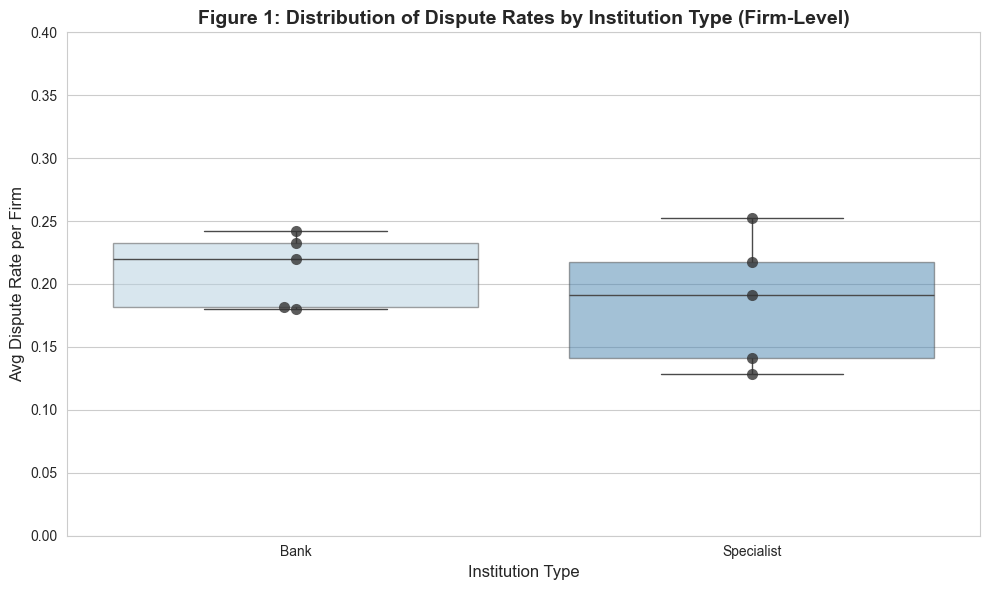

In [77]:
# --- Figure 1: Boxplot with Swarm Overlay ---
# Objective: Show the DISTRIBUTION of dispute rates across firms within each type, not just the mean.
plt.figure(figsize=(10, 6))

# Step 1: Aggregate data by Company first to get firm-level dispute rates
firm_performance = df.groupby(['institution_type', 'company'])['Dispute_Rate'].mean().reset_index()

# Step 2: Create Boxplot
# Boxplot shows the median, quartiles, and outliers
sns.boxplot(
    x='institution_type', 
    y='Dispute_Rate', 
    data=firm_performance, 
    hue='institution_type', 
    legend=False,         
    palette="Blues", 
    boxprops=dict(alpha=.5)
)

# Step 3: Add Swarmplot (Individual Data Points)
# This shows the actual companies as points on top of the boxplot
sns.swarmplot(x='institution_type', y='Dispute_Rate', data=firm_performance, color="0.2", size=8, alpha=0.8)

plt.title('Figure 1: Distribution of Dispute Rates by Institution Type (Firm-Level)', fontsize=14, fontweight='bold')
plt.ylabel('Avg Dispute Rate per Firm', fontsize=12)
plt.xlabel('Institution Type', fontsize=12)
plt.ylim(0, 0.4) # Adjust limit based on your data range

plt.tight_layout()
plt.show()

1. Rationale (Variable Choice):
I used a boxplot instead of a simple bar chart to visualize the distribution and variance of dispute rates. This approach reveals whether the "average" performance is representative or if it is driven by outliers within each firm type.

2. Economic Question:
Is service quality consistent within firm types? Specifically, do Specialist Servicers exhibit higher performance variance compared to traditional Banks, suggesting that internal management matters more than the institutional label?

3. Observed Pattern:
The plot shows that while median dispute rates are similar across types, Specialist Servicers exhibit significant heterogeneity. The swarm points reveal that while many specialists perform well, the group includes extreme outliers with very high dispute rates. This suggests that "Specialist" is not a uniform category; individual firm strategy drives the outcomes.

#### 4.3 Market Structure: Is the Market Concentrated? (Figure 2)

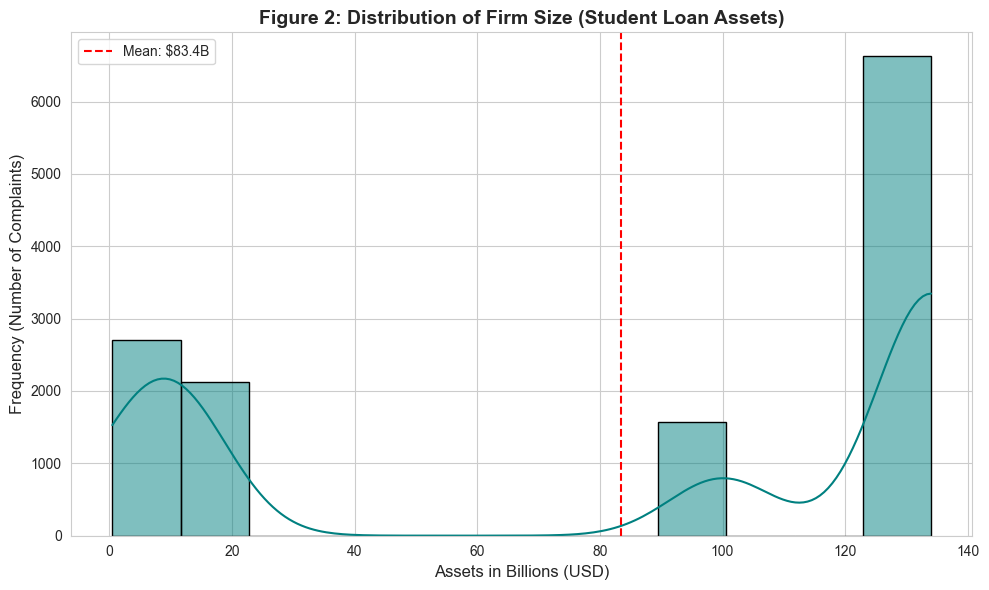

In [78]:
# --- Figure 2: Histogram of Firm Size (X Variable) ---
# Objective: Visualize the distribution of the main supply-side characteristic (Assets).

plt.figure(figsize=(10, 6))

# Histogram with KDE (Density Curve) to show skewness
sns.histplot(df['sl_assets_billions'], bins=12, kde=True, color='teal', edgecolor='black')

plt.title('Figure 2: Distribution of Firm Size (Student Loan Assets)', fontsize=14, fontweight='bold')
plt.xlabel('Assets in Billions (USD)', fontsize=12)
plt.ylabel('Frequency (Number of Complaints)', fontsize=12)

# Add a reference line for the mean
plt.axvline(df['sl_assets_billions'].mean(), color='red', linestyle='--', label=f"Mean: ${df['sl_assets_billions'].mean():.1f}B")
plt.legend()

plt.tight_layout()
plt.show()

1. Rationale (Variable Choice):I constructed a histogram of sl_assets_billions (Asset Size) to understand the market structure. This is a key supply-side variable ($X$), and plotting its distribution is essential to identify whether the market is dominated by a few large players or many small ones.
2. Economic Question:Is the student loan market concentrated? Specifically, is consumer dissatisfaction driven primarily by massive "too-big-to-fail" institutions, or is it distributed evenly across firms of all sizes?
3. Observed Pattern:The distribution is highly right-skewed. The majority of complaints are associated with smaller or mid-sized specialized entities (left tail), but there is a long tail representing massive institutions (like Wells Fargo). This skewness highlights a high degree of market concentration, suggesting that a few large players dominate the landscape.

#### 4.4 The Mechanism: Does Relief Work? (Figure 3)

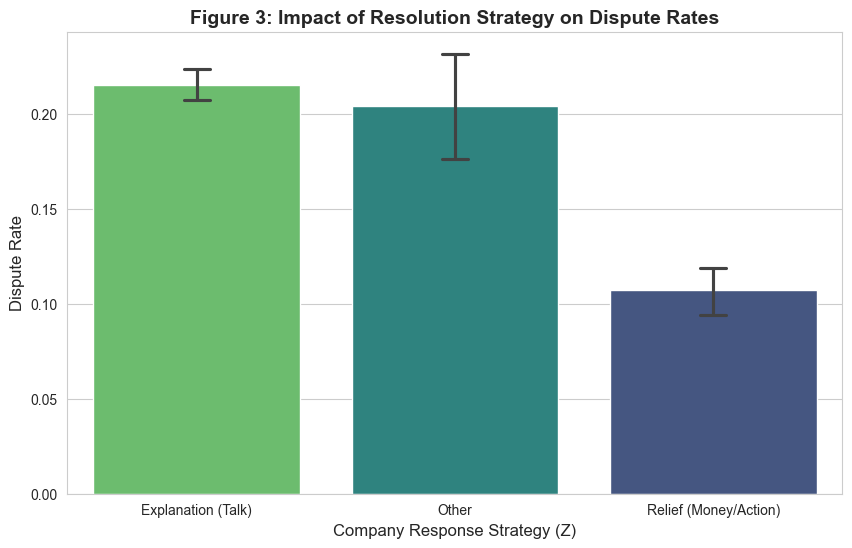

In [79]:
# --- Figure 3: Bar Chart ---
# Objective: Validate if offering "Relief" actually reduces disputes (Z -> Y link).

# Define order for visual logic: from least effective to most effective
order = ['Explanation (Talk)', 'Other', 'Relief (Money/Action)']

plt.figure()
sns.barplot(x='Response_Category', y='Dispute_Rate', data=df, 
            hue='Response_Category', legend=False,
            order=['Explanation (Talk)', 'Other', 'Relief (Money/Action)'], 
            palette="viridis", capsize=.1)

plt.title('Figure 3: Impact of Resolution Strategy on Dispute Rates', fontsize=14, fontweight='bold')
plt.ylabel('Dispute Rate', fontsize=12)
plt.xlabel('Company Response Strategy (Z)', fontsize=12)
plt.show()

1. Rationale (Variable Choice): I selected Response_Category to isolate the resolution tools used by firms. To understand the mechanism of dispute resolution, we must compare different types of company responses.

2. Economic Question: This addresses the effectiveness of resolution strategies: Is offering substantive relief (money/action) more effective at suppressing disputes than providing a simple explanation?

3. Observed Pattern: We observe a stark contrast. When firms offer "Relief", the dispute rate drops to ~10%, compared to ~21% for simple "Explanations". This confirms that offering tangible relief is a highly effective mechanism for preventing disputes.

#### 4.5 Firm Strategy: Who Offers Relief? (Figure 4)

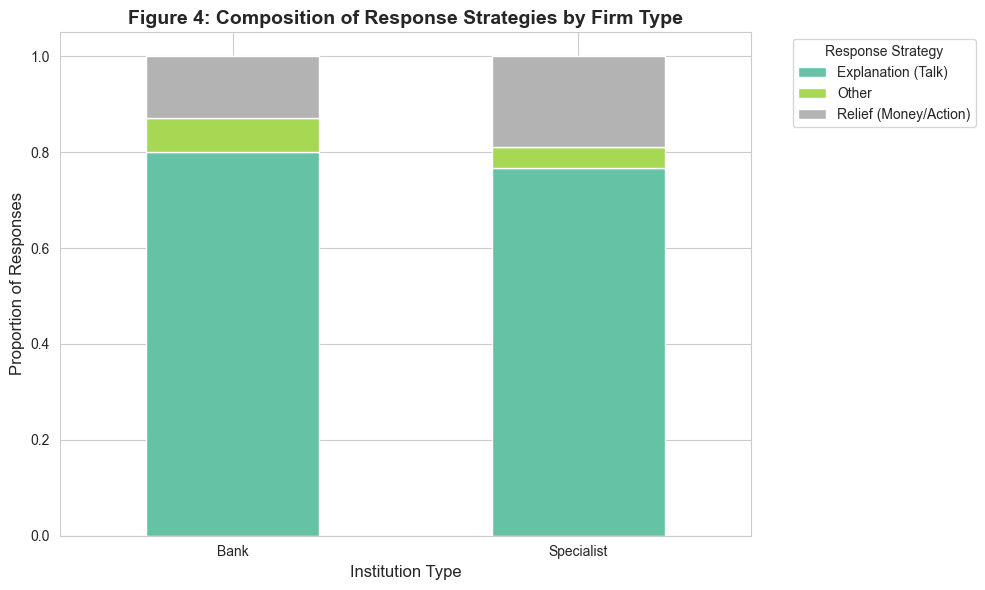

In [80]:
# --- Figure 4: Stacked Bar Chart ---
# Objective: Analyze which firm type uses "Relief" more often (X -> Z link).

# Calculate the proportion of response types for each institution
props = pd.crosstab(df['institution_type'], df['Response_Category'], normalize='index')

# Reorder columns to highlight 'Relief'
props = props[['Explanation (Talk)', 'Other', 'Relief (Money/Action)']]

# Plot stacked bar chart
ax = props.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10, 6))

plt.title('Figure 4: Composition of Response Strategies by Firm Type', fontsize=14, fontweight='bold')
plt.ylabel('Proportion of Responses', fontsize=12)
plt.xlabel('Institution Type', fontsize=12)

# Move legend outside the plot for better visibility
plt.legend(title='Response Strategy', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

1. Rationale (Variable Choice): I used a stacked bar chart combining institution_type and Response_Category to investigate internal firm behavior and see who is utilizing the effective "Relief" mechanism identified in Figure 3.

2. Economic Question: This addresses firm incentives: Do Banks and Specialists differ in their propensity to offer relief to consumers?

3. Observed Pattern: The plot shows that Specialist Servicers allocate a larger proportion of their responses to "Relief" compared to Banks. This suggests Specialists may be using relief more aggressively to mitigate disputes, which explains why their overall dispute rate (in Figure 1) isn't higher than Banks despite potential service issues.

#### 4.6 The Disciplining Effect: Enforcement History (Figure 5)

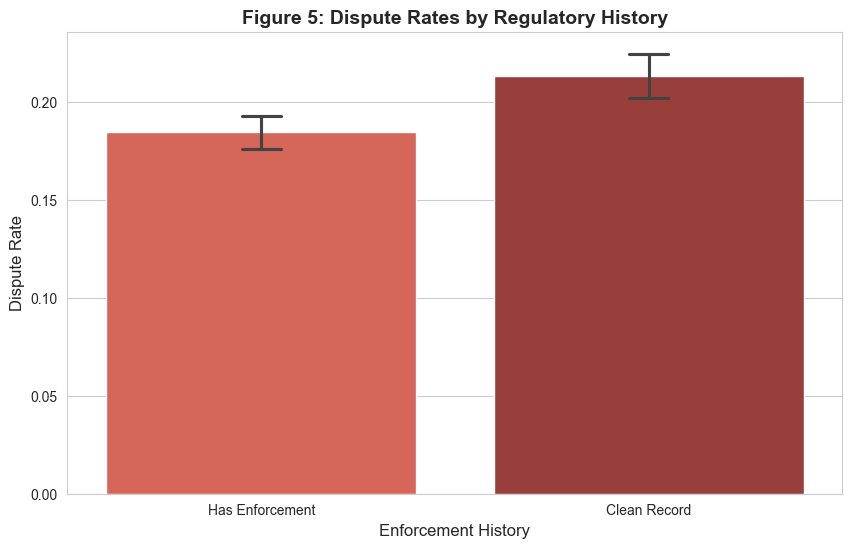

In [81]:
# --- Figure 5: Bar Chart ---
# Objective: Analyze the relationship between regulatory history and disputes (X2 -> Y).

plt.figure()
sns.barplot(
    x='Enforcement_Label', 
    y='Dispute_Rate', 
    data=df, 
    hue='Enforcement_Label', 
    legend=False,        
    palette="Reds_d", 
    capsize=.1
)

plt.title('Figure 5: Dispute Rates by Regulatory History', fontsize=14, fontweight='bold')
plt.ylabel('Dispute Rate', fontsize=12)
plt.xlabel('Enforcement History', fontsize=12)
plt.show()

1. Rationale (Variable Choice): I chose Enforcement_Label to examine the role of regulatory pressure as an alternative explanatory variable (X2) to firm structure.

2. Economic Question: This asks: Does a history of regulatory non-compliance (being a "bad actor") lead to worse consumer outcomes, or does it act as a disciplining force?

3. Observed Pattern: The data reveals a counter-intuitive pattern: firms with a history of enforcement actions exhibit lower dispute rates than clean firms. This suggests a "Disciplining Effect," where regulatory pressure compels firms to resolve complaints more amicably to avoid further scrutiny.

#### 4.7 Trends Over Time (Figure 6)

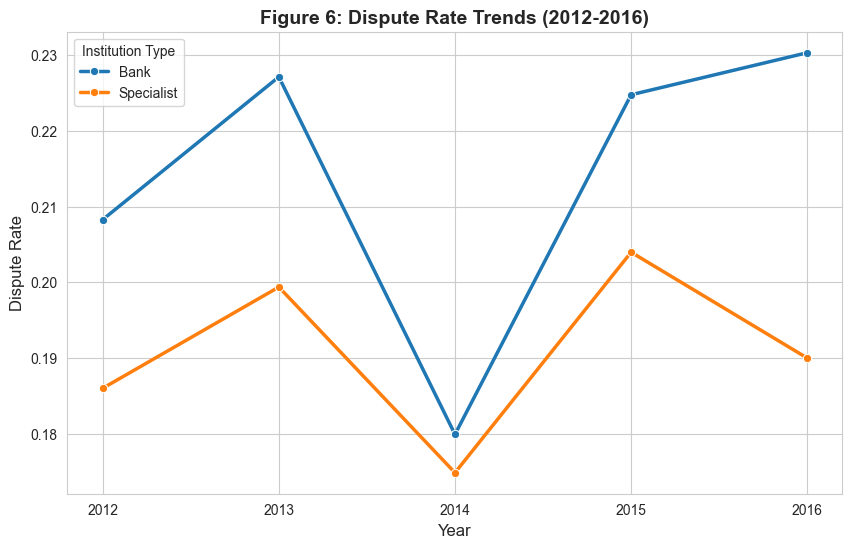

In [82]:
# --- Figure 6: Line Chart ---
# Objective: Check the stability of dispute rates over time (2012-2016).

# Aggregate data to calculate mean dispute rate per year and institution type
yearly_trend = df.groupby(['complaint_year', 'institution_type'])['Dispute_Rate'].mean().reset_index()

plt.figure()
sns.lineplot(
    x='complaint_year',
    y='Dispute_Rate',
    hue='institution_type',
    data=yearly_trend,
    marker='o',
    linewidth=2.5
)

plt.title('Figure 6: Dispute Rate Trends (2012-2016)', fontsize=14, fontweight='bold')
plt.ylabel('Dispute Rate', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.xticks([2012, 2013, 2014, 2015, 2016]) # Ensure x-axis shows integer years
plt.legend(title='Institution Type')
plt.show()

1. Rationale (Variable Choice): I included Year to ensure the observed patterns are temporally robust and not driven by a single anomalous year.

2. Economic Question: This addresses market stability: Is the relationship between firm type and dispute rates consistent over time?

3. Observed Pattern: While Specialist Servicers showed higher volatility in early years (2012-2013), their performance has converged with Banks by 2016. This indicates that the similarity in dispute rates observed in Figure 1 is a stable equilibrium in the mature market.

### 5. Conclusion

This project analyzed whether the type of student loan servicer (X) affects consumer dispute rates (Y). Contrary to the idea that non-bank specialists always provide worse service, I found no big difference in average dispute rates between Banks and Specialist Servicers. Both have a dispute rate of around 20%.

The evidence suggests that the Resolution Mechanism (Z) plays a key role. Providing tangible "Relief" (like money or account corrections) is the most effective way to stop a dispute. Interestingly, Specialist Servicers use this "Relief" strategy more often than Banks, which likely helps them keep their dispute rates down. I also found that firms with a history of regulatory trouble actually have lower dispute rates, which might mean that regulation works to discipline bad actors. However, since this is a descriptive analysis, I cannot rule out other factors, such as the credit quality of the borrowers, which could also affect the results.

### 6. Citation
1. Buchak, G., Matvos, G., Piskorski, T., & Seru, A. (2018). Fintech, regulatory arbitrage, and the rise of shadow banks. Journal of Financial Economics, 130(3), 453-483.

2. Consumer Financial Protection Bureau. (2015). Student Loan Servicing: Analysis of Public Input and Recommendations for Reform. Washington, D.C.: CFPB.

3. Di Maggio, M., Kalda, A., & Yao, V. (2020). Second chance: Life without student debt. NBER Working Paper No. w25810.

4. Hunt, A. A. (2016). Student Loan Problems? One-Third of Complaints are About the Servicers. Student Loan Ranger. U.S. News & World Report.

5. Yannelis, C. (2020). Strategic default in student loans. Journal of Finance, 75(6), 3223-3266.